## Overview

This notebook builds a synthetic multi-asset portfolio with known ground truth. The point is to have something where I know the "true" underlying price dynamics, so later I can check whether the Kalman filter and HMM are actually recovering that signal before testing them on real financial data.

Four correlated assets, each with its own drift and volatility:

- EQTY, generic equity
- BOND, fixed income
- GOLD, safe haven commodity
- TECH, higher growth, higher volatility

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [7]:
from dataclasses import dataclass

# Creating a struct because I can
@dataclass
class Asset:
    ticker: str
    mu: float
    sigma: float

# Definition of assets
# mu being expected returns and sigma being volatility
assets = [
    Asset("EQTY", mu=0.07, sigma=0.18),
    Asset("BOND", mu=0.03, sigma=0.05),
    Asset("GOLD", mu=0.02, sigma=0.15),
    Asset("TECH", mu=0.12, sigma=0.35),
]

# We create a correlation matrix, as a standard equity portfolio will have significant overlap with tech    
corr = np.array([
    [1.00,  -0.30, 0.05, 0.55],
    [-0.30,  1.00, 0.10, -0.25],
    [0.05,   0.10, 1.00, 0.00],
    [0.55,  -0.25, 0.00, 1.00],
])

# We create starting values for our simulation, indexing everything to 100
s0 = np.array([100, 100, 100, 100])

Now that we have initial conditions set up we create a function that let's us simulate a market using brownian motion
Having done some research I know the best way to make them correlate with eachother is to go take a second look on cholesky decompositions

In [ ]:
# Simulates correlated geometric Brownian Motion for N assets.
# Each asset gets assigned a drift and a volatility
# Correlation imposed using cholesky
def simulate_gbm_market(assets, corr, s0, n_days=1000, dt=1/252, seed=None):

    rng = np.random.default_rng(seed)
    n_assets = len(assets)

    # Pull mu/sigma out of the Asset objects into arrays for vectorized math
    mu = np.array([a.mu for a in assets])
    sigma = np.array([a.sigma for a in assets])
    tickers = [a.ticker for a in assets]

    # Cholesky: turn independent noise into correlated noise
    L = np.linalg.cholesky(corr)
    z = rng.standard_normal((n_days, n_assets))
    correlated_z = z @ L.T

    # GBM in log space (the -0.5*sigma^2 is the Itô correction)
    log_returns = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * correlated_z
    log_prices = np.log(s0) + np.cumsum(log_returns, axis=0)
    prices = np.exp(log_prices)

    dates = pd.bdate_range("2023-01-01", periods=n_days)
    return pd.DataFrame(prices, index=dates, columns=tickers)


# Run it
prices = simulate_gbm_market(assets, corr, s0, n_days=1000, seed=None)
prices.head()

,EQTY,BOND,GOLD,TECH
2023-01-02,101.869635,99.495712,99.404763,106.519316
2023-01-03,101.014289,99.139638,98.557835,103.616214
2023-01-04,99.751075,99.246635,98.061318,102.214293
2023-01-05,98.718405,99.828206,99.122764,100.773199
2023-01-06,99.475552,99.920099,98.764130,104.179508


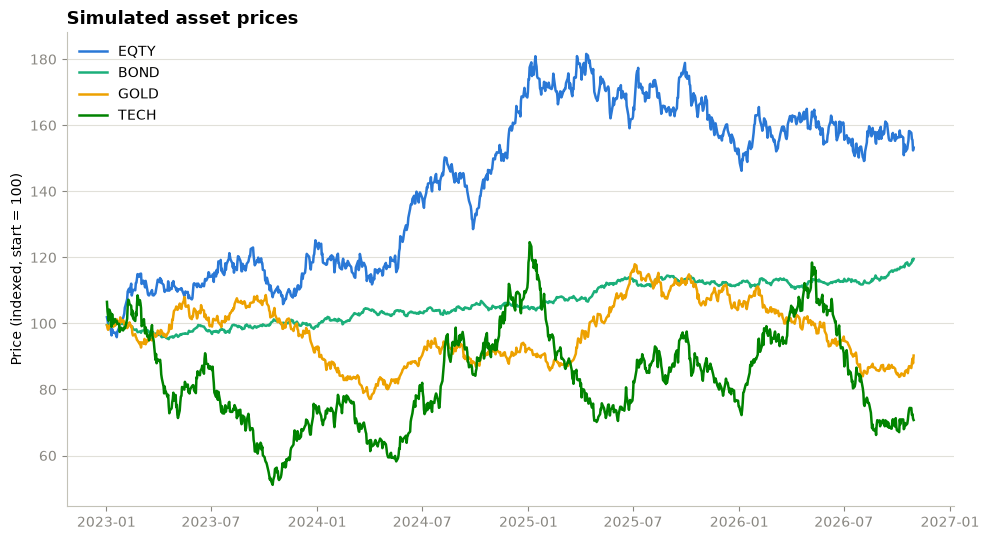

In [11]:
COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#008300"]

fig, ax = plt.subplots(figsize=(10, 5.5))

for ticker, color in zip(prices.columns, COLORS):
    ax.plot(prices.index, prices[ticker], color=color, linewidth=1.8, label=ticker)

ax.set_title("Simulated asset prices", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Price (indexed, start = 100)")

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")

ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="#898781")

ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

**We now have a reliable way to simulate the markets from from our known outputs**
The next step is to make a Kalman filter to retrive the underlying data

**Because we know the actual underlying characteristics of this data, we can use it to tune the parameters of our Kalman filter**, we just have to be careful not to overfit the data.